<a href="https://colab.research.google.com/github/jaidatta71/ML---Berkeley/blob/main/Coupon_Acceptance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/drive/MyDrive/assignment5_1_starter/data/coupons.csv')

In [4]:
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [5]:
data = pd.read_csv('drive/MyDrive/assignment5_1_starter/data/coupons.csv')
df = pd.read_csv('drive/MyDrive/assignment5_1_starter/data/coupons.csv')

In [6]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

### Drop Duplicates

In [7]:
data = data.drop_duplicates()
data.shape

(12610, 26)

2. Investigate the dataset for missing or problematic data.

In [8]:
missing_counts = data.isnull().sum().sort_values(ascending=False)
print(missing_counts)

car                     12502
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 150
RestaurantLessThan20      129
Bar                       107
weather                     0
temperature                 0
destination                 0
passanger                   0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
income                      0
occupation                  0
has_children                0
education                   0
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


3. Decide what to do about your missing data -- drop, replace, other...

In [11]:
# Imputation of Null Values with Mode for the columns with Null except for car

columns_with_Nulls = ['CoffeeHouse','Restaurant20To50','CarryAway','RestaurantLessThan20','Bar']
for i in columns_with_Nulls:
  print(data[i].isnull().sum())
  data[i] = data[i].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
  print(data[i].isnull().sum())

# Encoding categorical variables
#from sklearn.preprocessing import LabelEncoder
#for i in ['CoffeeHouse','Restaurant20To50','CarryAway','RestaurantLessThan20','Bar']:
#  le = LabelEncoder()
#  data[str(i)+'_encoded'] = le.fit_transform(data[i])

#data.select_dtypes(include=['float64', 'int64']).apply(lambda x: x.unique())

217
0
189
0
150
0
129
0
107
0


In [12]:
missing_counts = data.isnull().sum().sort_values(ascending=False)
print(missing_counts)

car                     12502
destination                 0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
passanger                   0
maritalStatus               0
has_children                0
occupation                  0
education                   0
income                      0
Bar                         0
CoffeeHouse                 0
CarryAway                   0
RestaurantLessThan20        0
Restaurant20To50            0
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [51]:
#proportion = data.query("Y == 1").shape[0]/data.shape[0]
#print(f"Proportion of the total observations chose to accept the coupon: {proportion}")
proportion = data.query('Y==1').shape[0]*100/data.shape[0]
print(f"Proportion of the total observations chose to accept the coupon: {proportion}")

#categorical_columns = data.select_dtypes(include=['object','category']).columns     # Adjust as necessary

#for i in categorical_columns:
#  if i!= 'Y':
#    contingency_table = pd.crosstab(index= data[i], columns= data["Y"])
#    print(f"contingency_table for {i}:\n", contingency_table)
#    print("\n")

Proportion of the total observations chose to accept the coupon: 56.75654242664552


#### Covert Age into Numeric

In [28]:
data["age"] = data["age"].str.replace("50plus","50").str.replace("below21","20")

5. Use a Bar plot to visualize the `coupon` column. - Coffee coupons are given out more

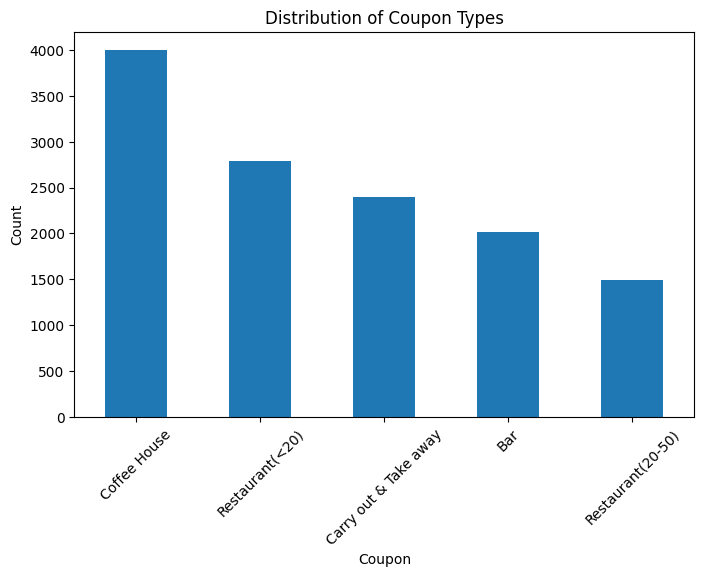

In [14]:
# Highest for take away & Restaurant<20.
# Lowest for Bar
#sns.barplot(data, x="coupon", y="Y")
#plt.xticks(rotation=45)

#pd.crosstab(data.query("Y==1").direction_same, data.query("Y==1").Y, normalize = True)

#sns.countplot(data.query("Y==1"), x="direction_same")
#plt.xticks(rotation=45)

df['coupon'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

6. Use a histogram to visualize the temperature column.

<Axes: xlabel='temperature', ylabel='Count'>

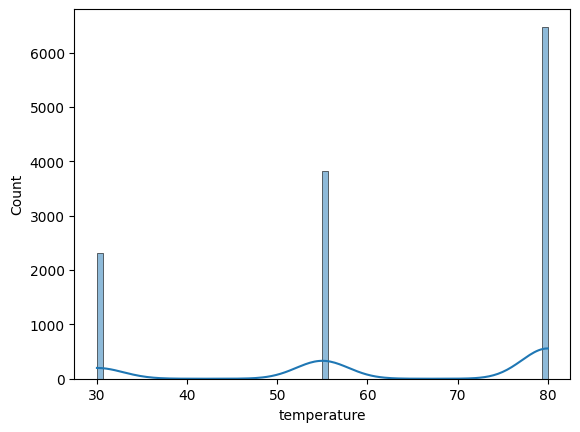

In [15]:
#sns.histplot(data['temperature'])
sns.histplot(data['temperature'].dropna(), bins=80, kde=True)

## Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [16]:
bar = data[data["coupon"].str.contains("Bar")]
#bar = data.dropna(subset=['Bar'])
bar.info()

#unique_combined = pd.unique(df[['Bar', 'Bar_encoded']].values.ravel())
#print(unique_combined)

<class 'pandas.core.frame.DataFrame'>
Index: 2010 entries, 9 to 12682
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           2010 non-null   object
 1   passanger             2010 non-null   object
 2   weather               2010 non-null   object
 3   temperature           2010 non-null   int64 
 4   time                  2010 non-null   object
 5   coupon                2010 non-null   object
 6   expiration            2010 non-null   object
 7   gender                2010 non-null   object
 8   age                   2010 non-null   object
 9   maritalStatus         2010 non-null   object
 10  has_children          2010 non-null   int64 
 11  education             2010 non-null   object
 12  occupation            2010 non-null   object
 13  income                2010 non-null   object
 14  car                   13 non-null     object
 15  Bar                   2010 non-null   obje

## Bar Coupons Acceptance rate

2. What proportion of bar coupons were accepted?


### Only 40% of BAR coupons accepted

In [52]:
bar_proportion = bar.query("Y == 1").shape[0]*100/bar.shape[0]
bar_proportion

40.995024875621894

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


### People who went to bar 3 or fewer times a month have more acceptance rate of Coupons ###

In [18]:
# went to a bar 3 or fewer times a month
bar.query("Bar == '1~3' and Y==1").shape[0]   # 257
# went to a bar more than 3 times a month
bar_grp = ["4~8",	"gt8"]
bar.query("Bar in @bar_grp and Y==1").shape[0]     #158

# Acceptance_rate between those who went to a bar 3 or fewer to those who went more
bar.query("Bar == '1~3' and Y==1").shape[0]/bar.query("Bar in @bar_grp and Y==1").shape[0]

#acc_less_than_3 = bar.query('Bar == "1~3" and Y == 1').shape[0]
#print(acc_less_than_3 )
#more_than_3 = ['gt8','4~8']
#acc_more_than_3 = bar.query('Bar in @more_than_3 and Y == 1').shape[0]
#print(acc_more_than_3)

1.6797385620915033

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


### The difference is 22.723735408560312

In [55]:
#  17% Acceptance rate between drivers who go to a bar more than once and are over 25 to the all others
bar_list = ['1~3', '4~8', 'gt8']

#bar.query('Bar in @bar_list' and )

#bar["age"] = bar["age"].str.replace("50plus","50").str.replace("below21","20")
bar["age"] = pd.to_numeric(bar["age"])
bar['age'].unique()
bar.query("age > 25").shape[0]
bar.query("Bar in @bar_list and age > 25 and Y==1").shape[0]      # 292
#bar.query("not (Bar in @bar_list and age > 25 and Y==1)").shape[0] # 1718
bar.query("Bar not in @bar_list or age <= 25 and Y==1").shape[0]

# Acceptance_rate between those who go to a bar more than once a month and are over the age of 25 to the all others
bar.query("Bar in @bar_list and age > 25 and Y==1").shape[0]*100/bar.query("not (Bar in @bar_list or age <= 25 and Y==1)").shape[0]

/tmp/ipykernel_1069/3807327857.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar["age"] = pd.to_numeric(bar["age"])


22.723735408560312

In [20]:
#bar_coupons = data.query('coupon == "Bar"')
#ages = ['21', 'below21']
# for bar going frequnecy 1 time or more
#bar_freq = ['1~3', 'gt8', '4~8']
# drivers who go to a bar more than once a month and are over the age of 25
#drivers_who_go_to_a_bar_more_than_once_and_over_age_of_25 = bar_coupons.query('(Y == 1) and (Bar in @bar_freq) and (age not in @ages)')

#print(drivers_who_go_to_a_bar_more_than_once_and_over_age_of_25.shape[0])
#print(bar_coupons.shape[0])
#rest = bar_coupons.query('(Y != 1) or (Bar not in @bar_freq) or (age in @ages)')
#print(rest.shape[0])

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [57]:
# People who go to bar more than once, Not a Kid and Not in Farming/Fishing have More acceptance rate of Coupons

bar_freq = ['1~3', '4~8', 'gt8']             # who go to bars more than once a month
kid_y =  ['Kid(s)']                          # kid
occ =   ['Farming Fishing & Forestry']       # farming, fishing, or forestry

a = bar.query('(Bar in @bar_freq) and (Y == 1) and (passanger not in @kid_y) and (occupation not in @occ)').shape[0]  # 393. who go to bar more than once, not a kid and not in farming, fishing, or forestry
b = bar.query("~(Bar in @bar_freq) and (Y == 1) and (passanger not in @kid_y) and (occupation not in @occ)").shape[0] # 385
bar.query('(Bar in @bar_freq) and (Y == 1) and (passanger not in @kid_y) and (occupation not in @occ)').shape[0] / bar.query(" not (Bar in @bar_freq) and (Y == 1) and (passanger not in @kid_y) and (occupation not in @occ)").shape[0]

#plt.figure(figsize=(30, 15))
#sns.barplot(x='occupation', y='Y', hue='passanger', data=bar.query('passanger not in @kid_y'), palette='Set1')
#plt.xticks(rotation=45)

1.0207792207792208

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



### Bar visit >1/month, No Kids, Not Widowed have higher acceptance rate

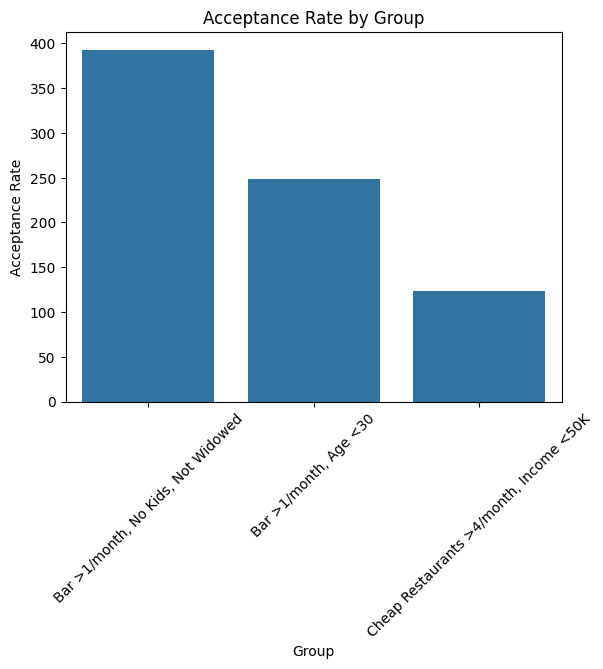

In [22]:
bar_freq =  ['1~3', '4~8', 'gt8']             # who go to bars more than once a month
kid_y   =   ['Kid(s)']                        # kid
widow   =   ['Widowed']                       # widows
num_times = ['4~8','gt8']
data["income"]  = data["income"].str.replace("$100000 or More","100000").str.replace("Less than $12500","12500")
x_income = ['12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']

#  People who had no Kid passengers, and not widowed visit bar multiple times in a month
a= bar.query('(Bar in @bar_freq) and (Y == 1) and (passanger not in @kid_y) and (maritalStatus not in @widow)').shape[0]      #  393
a1= bar.query('(Bar in @bar_freq) and (passanger not in @kid_y) and (maritalStatus not in @widow)').shape[0]      #  393

#  People under 30 yrs visit bar multiple times in a month
b = bar.query('(Bar in @bar_freq)  and (Y == 1) and (age < 30)').shape[0]
b1 = bar.query('(Bar in @bar_freq)  and (age < 30)').shape[0]
#sns.histplot(data['age'], bins=80, kde=True)
#sns.distplot(data['age'])                      #  249

#  People who go to cheap restaurants more than 4 times a month and income is less than 50K
c = bar.query('(RestaurantLessThan20 in @num_times) and (Y == 1) and (income in @x_income)').shape[0]      # 124
c1 = bar.query('(RestaurantLessThan20 in @num_times) and (income in @x_income)').shape[0]      # 124

Comp_acc_rates = pd.DataFrame({
    'Group': ['Bar >1/month, No Kids, Not Widowed', 'Bar >1/month, Age <30', 'Cheap Restaurants >4/month, Income <50K'],
    'Acceptance Rate': [a, b, c]
})

sns.barplot(
    data=Comp_acc_rates,
    x='Group',
    y='Acceptance Rate'
)

plt.title('Acceptance Rate by Group')
plt.xticks(rotation=45)
plt.show()

## Bar >1/month, No Kids, Not Widowed have Higher Acceptance rates

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

## 4 to 8 times visitors to Bar are more likely to accept coupons.

<Figure size 800x500 with 0 Axes>

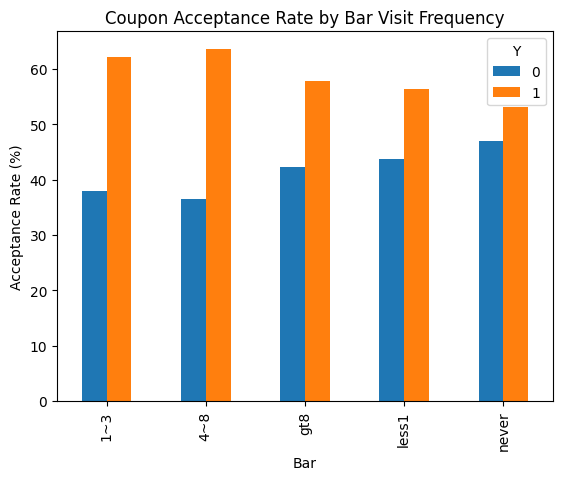

In [23]:

bar_acceptance = pd.crosstab(data["Bar"], data['Y'], normalize='index') * 100
bar_acceptance.sort_values(by='Bar', ascending=False)

plt.figure(figsize=(8,5))
bar_acceptance.plot(kind='bar')

plt.ylabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate by Bar Visit Frequency')
plt.show()

# WHERE IS ACCEPTANCE HIGHER?

## Coffee Coupons Acceptance rate - Less frequent Coffee house visitors accepted more coupons

<Figure size 800x500 with 0 Axes>

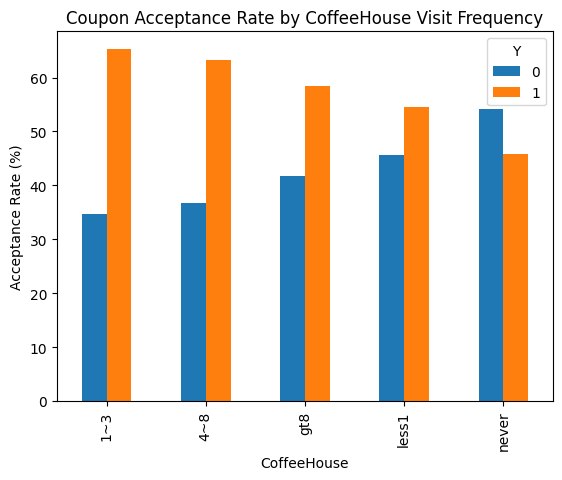

In [24]:
CoffeeHouse_acceptance = pd.crosstab(data["CoffeeHouse"], data['Y'], normalize='index') * 100
CoffeeHouse_acceptance.sort_values(by='CoffeeHouse', ascending=False)

plt.figure(figsize=(8,5))
CoffeeHouse_acceptance.plot(kind='bar')

plt.ylabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate by Visit Frequency')
plt.show()

### Cheap restaurant Acceptance rate - More frequenct visitors accept coupons

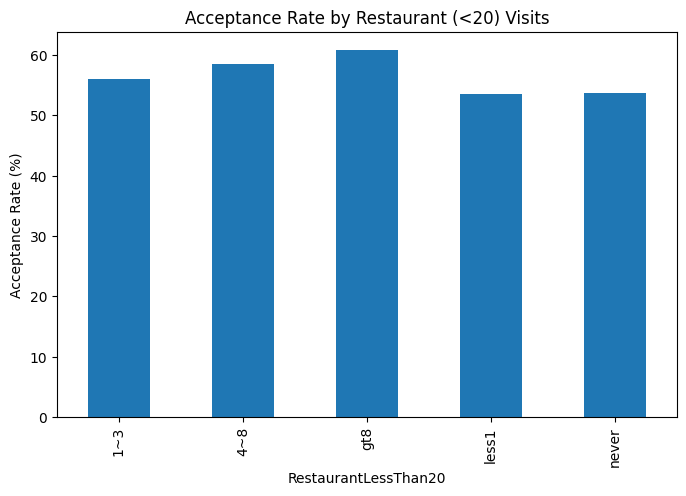

In [58]:
rest20_acceptance = pd.crosstab(
    df['RestaurantLessThan20'],
    df['Y'],
    normalize='index'
)[1] * 100

plt.figure(figsize=(8,5))
rest20_acceptance.plot(kind='bar')

plt.ylabel('Acceptance Rate (%)')
plt.title('Acceptance Rate by Restaurant (<20) Visits')
plt.show()

### Expensive restaurant Acceptance rate - More frequenct visitors accept coupons

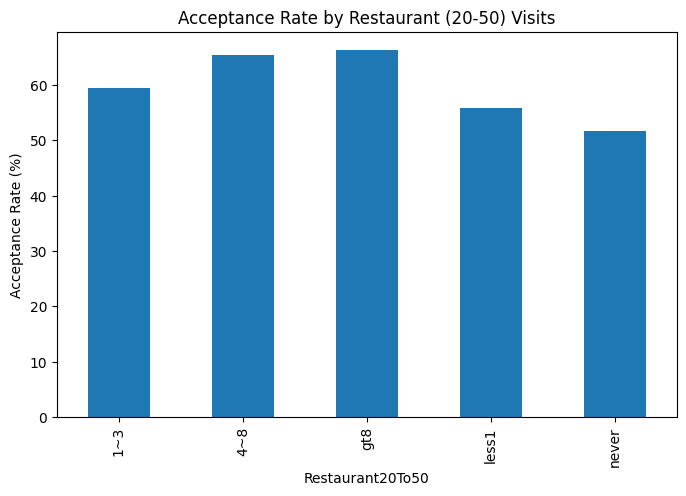

In [60]:
rest2050_acceptance = pd.crosstab(
    df['Restaurant20To50'],
    df['Y'],
    normalize='index'
)[1] * 100

plt.figure(figsize=(8,5))
rest2050_acceptance.plot(kind='bar')

plt.ylabel('Acceptance Rate (%)')
plt.title('Acceptance Rate by Restaurant (20-50) Visits')
plt.show()

### Acceptance by Age Group - People under 30 accepts more coupons

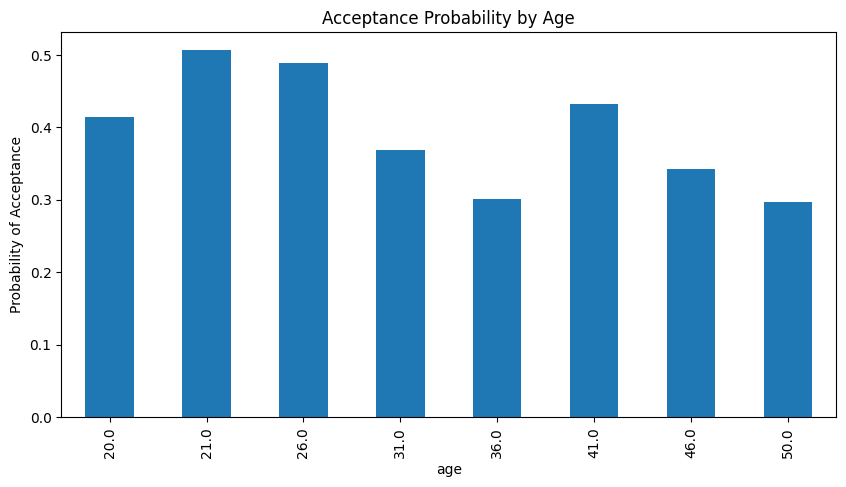

In [41]:
age_acceptance = pd.crosstab(
    data['age'],
    data['Y'],
    normalize='index'
)[1]

age_acceptance.sort_index().plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel('Probability of Acceptance')
plt.title('Acceptance Probability by Age')

plt.show()

### Coupon Type Acceptance Rates - Carry Out & Cheap restaurants have higher acceptncy. Bar has lower acceptancy

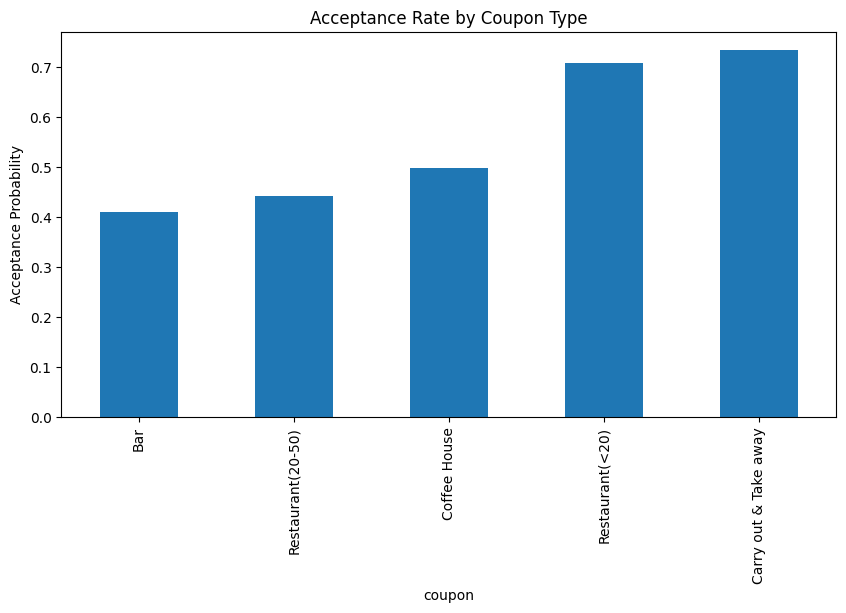

In [40]:
coupon_acceptance = pd.crosstab(
    data['coupon'],
    data['Y'],
    normalize='index'
)[1]

coupon_acceptance.sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel('Acceptance Probability')
plt.title('Acceptance Rate by Coupon Type')

plt.show()

## Summary Visualization

In [49]:
summary = pd.DataFrame({
    'Bar Acceptance %':
        pd.crosstab(data['Bar'],data['Y'],normalize='index')[1]*100,

    'Coffee Acceptance %':
        pd.crosstab(data['CoffeeHouse'],data['Y'],normalize='index')[1]*100,

    'Carry Away Acceptance %':
        pd.crosstab(data['CarryAway'],data['Y'],normalize='index')[1]*100,

    'Restaurant<20 Acceptance %':
        pd.crosstab(data['RestaurantLessThan20'],data['Y'],normalize='index')[1]*100
})
print(summary)

       Bar Acceptance %  Coffee Acceptance %  Carry Away Acceptance %  \
1~3           62.115073            65.301657                58.248175   
4~8           63.585434            63.237774                58.038661   
gt8           57.758621            58.355917                57.251908   
less1         56.311809            54.456552                49.810708   
never         53.093661            45.756959                53.289474   

       Restaurant<20 Acceptance %  
1~3                     56.207840  
4~8                     58.401351  
gt8                     60.764431  
less1                   53.259295  
never                   53.424658  


## Coupon Acceptance Rates by Temparature

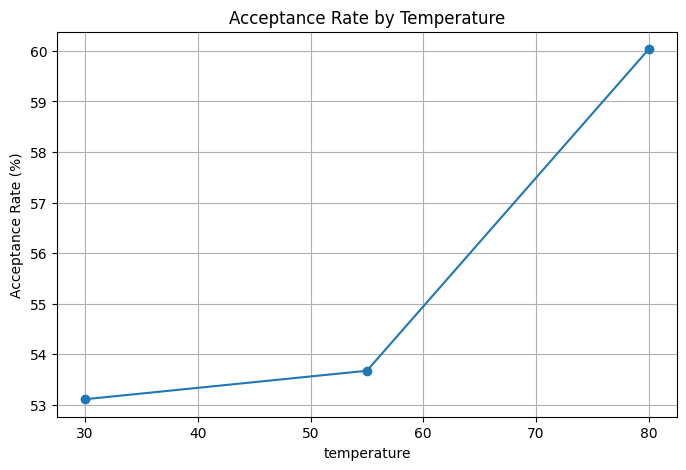

In [61]:
temp_acceptance = pd.crosstab(
    df['temperature'],
    df['Y'],
    normalize='index'
)[1] * 100

plt.figure(figsize=(8,5))
temp_acceptance.plot(marker='o')

plt.ylabel('Acceptance Rate (%)')
plt.title('Acceptance Rate by Temperature')
plt.grid()
plt.show()